In [1]:
import pandas as pd
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# ESC-50 paths
DATASET_PATH = PROJECT_ROOT / "dataset" / "ESC-50-master" / "ESC-50-master"
META_PATH = DATASET_PATH / "meta" / "esc50.csv"
AUDIO_PATH = DATASET_PATH / "audio"

print("Dataset Path:", DATASET_PATH)
print("Metadata File Exists:", META_PATH.exists())
print("Audio Folder Exists:", AUDIO_PATH.exists())

Dataset Path: C:\Natural_Sound_Statistics_Project\dataset\ESC-50-master\ESC-50-master
Metadata File Exists: True
Audio Folder Exists: True


In [2]:
# Load metadata

df = pd.read_csv(META_PATH)

print("Shape:", df.shape)

df.head()

Shape: (2000, 7)


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [3]:
print("Total Audio Files:", len(df))
print("Total Categories:", df["category"].nunique())

df["category"].value_counts()

Total Audio Files: 2000
Total Categories: 50


category
dog                 40
chirping_birds      40
vacuum_cleaner      40
thunderstorm        40
door_wood_knock     40
can_opening         40
crow                40
clapping            40
fireworks           40
chainsaw            40
airplane            40
mouse_click         40
pouring_water       40
train               40
sheep               40
water_drops         40
church_bells        40
clock_alarm         40
keyboard_typing     40
wind                40
footsteps           40
frog                40
cow                 40
brushing_teeth      40
car_horn            40
crackling_fire      40
helicopter          40
drinking_sipping    40
rain                40
insects             40
laughing            40
hen                 40
engine              40
breathing           40
crying_baby         40
hand_saw            40
coughing            40
glass_breaking      40
snoring             40
toilet_flush        40
pig                 40
washing_machine     40
clock_tick          40
sn

In [4]:
all_categories = sorted(df["category"].unique())

for i, category in enumerate(all_categories, start=1):
    print(f"{i:02d}. {category}")

01. airplane
02. breathing
03. brushing_teeth
04. can_opening
05. car_horn
06. cat
07. chainsaw
08. chirping_birds
09. church_bells
10. clapping
11. clock_alarm
12. clock_tick
13. coughing
14. cow
15. crackling_fire
16. crickets
17. crow
18. crying_baby
19. dog
20. door_wood_creaks
21. door_wood_knock
22. drinking_sipping
23. engine
24. fireworks
25. footsteps
26. frog
27. glass_breaking
28. hand_saw
29. helicopter
30. hen
31. insects
32. keyboard_typing
33. laughing
34. mouse_click
35. pig
36. pouring_water
37. rain
38. rooster
39. sea_waves
40. sheep
41. siren
42. sneezing
43. snoring
44. thunderstorm
45. toilet_flush
46. train
47. vacuum_cleaner
48. washing_machine
49. water_drops
50. wind


In [5]:
natural_categories = [
    "chirping_birds",
    "crow",
    "crickets",
    "frog",
    "insects",
    "rain",
    "wind",
    "thunderstorm",
    "sea_waves",
    "water_drops",
    "pouring_water",
    "crackling_fire",
    "rooster"
]

print("Number of Natural Categories:", len(natural_categories))
natural_categories

Number of Natural Categories: 13


['chirping_birds',
 'crow',
 'crickets',
 'frog',
 'insects',
 'rain',
 'wind',
 'thunderstorm',
 'sea_waves',
 'water_drops',
 'pouring_water',
 'crackling_fire',
 'rooster']

In [6]:
natural_df = df[df["category"].isin(natural_categories)]

print("Filtered Dataset Shape:", natural_df.shape)

natural_df["category"].value_counts()

Filtered Dataset Shape: (520, 7)


category
chirping_birds    40
thunderstorm      40
crow              40
pouring_water     40
water_drops       40
wind              40
frog              40
crackling_fire    40
rain              40
insects           40
rooster           40
sea_waves         40
crickets          40
Name: count, dtype: int64

In [7]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

In [8]:
sample_row = natural_df.iloc[0]

sample_row

filename    1-100038-A-14.wav
fold                        1
target                     14
category       chirping_birds
esc10                   False
src_file               100038
take                        A
Name: 1, dtype: object

In [9]:
audio_file = AUDIO_PATH / sample_row["filename"]

print(audio_file)
print(audio_file.exists())

C:\Natural_Sound_Statistics_Project\dataset\ESC-50-master\ESC-50-master\audio\1-100038-A-14.wav
True


In [10]:
signal, sr = librosa.load(audio_file, sr=None)

print("Sample Rate:", sr)
print("Number of Samples:", len(signal))
print("Duration (seconds):", len(signal) / sr)

Sample Rate: 44100
Number of Samples: 220500
Duration (seconds): 5.0


In [11]:
print("Minimum Amplitude :", np.min(signal))
print("Maximum Amplitude :", np.max(signal))
print("Mean Amplitude    :", np.mean(signal))
print("Std Deviation     :", np.std(signal))

Minimum Amplitude : -0.48049927
Maximum Amplitude : 0.54556274
Mean Amplitude    : -1.3780659e-06
Std Deviation     : 0.061433855


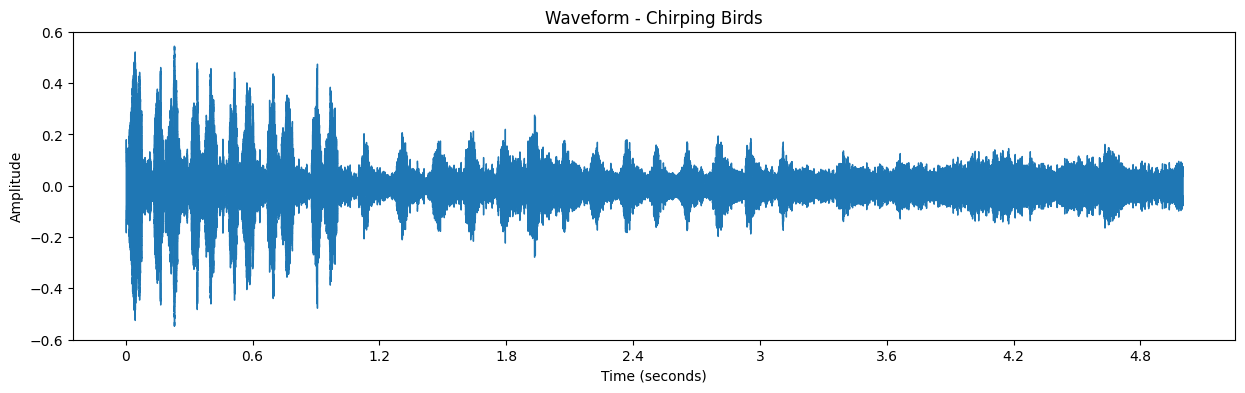

In [12]:
plt.figure(figsize=(15,4))

librosa.display.waveshow(signal, sr=sr)

plt.title("Waveform - Chirping Birds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

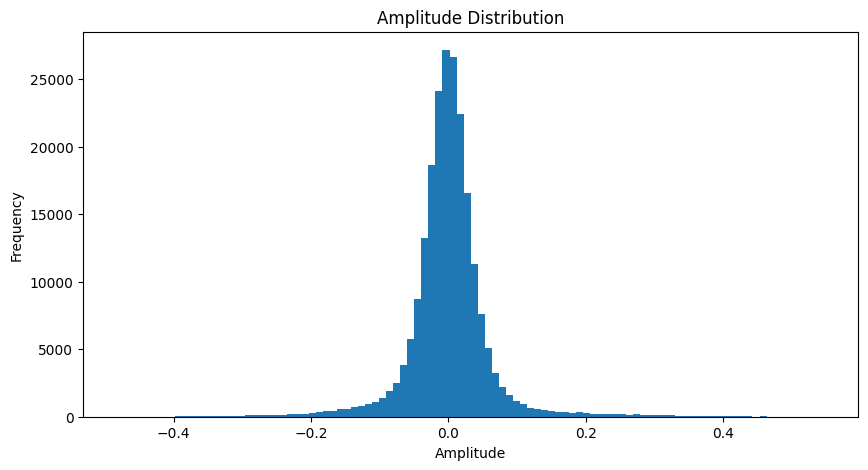

In [13]:
plt.figure(figsize=(10,5))

plt.hist(signal, bins=100)

plt.title("Amplitude Distribution")
plt.xlabel("Amplitude")
plt.ylabel("Frequency")

plt.show()

In [14]:
from scipy.stats import skew, kurtosis

print("Skewness :", skew(signal))
print("Kurtosis :", kurtosis(signal))

Skewness : 0.3929884
Kurtosis : 10.404342


# Statistical Feature Extraction for All Natural Sounds

In [15]:
from scipy.stats import skew, kurtosis
import librosa
import numpy as np
import pandas as pd

features = []

for _, row in natural_df.iterrows():

    file_path = AUDIO_PATH / row["filename"]

    signal, sr = librosa.load(file_path, sr=None)

    features.append({
        "filename": row["filename"],
        "category": row["category"],
        "mean": np.mean(signal),
        "std": np.std(signal),
        "min": np.min(signal),
        "max": np.max(signal),
        "skewness": skew(signal),
        "kurtosis": kurtosis(signal)
    })

features_df = pd.DataFrame(features)

print(features_df.shape)

features_df.head()

(520, 8)


,filename,category,mean,std,min,max,skewness,kurtosis
0,1-100038-A-14.wav,chirping_birds,-0.000001,0.061434,-0.480499,0.545563,0.392988,10.404342
1,1-101296-A-19.wav,thunderstorm,-0.000003,0.010946,-0.082306,0.102997,0.157899,8.572530
2,1-101296-B-19.wav,thunderstorm,-0.000010,0.016860,-0.164459,0.156952,-0.039740,10.883121
3,1-103298-A-9.wav,crow,-0.000253,0.136177,-0.945587,0.999969,0.027326,2.776779
4,1-115521-A-19.wav,thunderstorm,-0.000025,0.063967,-0.816681,0.980133,-0.052734,29.311878


In [16]:
category_summary = (
    features_df
    .groupby("category")
    .agg({
        "std": ["mean", "std"],
        "skewness": ["mean", "std"],
        "kurtosis": ["mean", "std"]
    })
)

category_summary.round(3)

std        skewness           kurtosis             
                 mean    std     mean    std        mean          std
category                                                             
chirping_birds  0.044  0.042    0.015  0.081    7.726000     7.416000
crackling_fire  0.055  0.087   -1.048  6.764  586.716980  1249.589966
crickets        0.047  0.048    0.050  0.113    4.050000     7.790000
crow            0.090  0.061    0.035  0.135    6.040000     7.617000
frog            0.106  0.069   -0.027  0.292   16.531000    23.132000
insects         0.058  0.049    0.065  0.542   18.254999    29.089001
pouring_water   0.034  0.034    0.147  0.357   41.911999    30.184999
rain            0.088  0.039    0.010  0.088    5.578000    25.846001
rooster         0.117  0.062    0.024  0.219    7.610000     4.001000
sea_waves       0.104  0.027   -0.003  0.059    3.075000     2.809000
thunderstorm    0.125  0.125   -0.094  0.253   10.528000     7.751000
water_drops     0.019  0.019    0.401  2.774  257.662994   385.362000
wind            0.139  0.116    0.013  0.245    1.026000     1.959000

In [17]:
features_df.groupby("category")["kurtosis"] \
           .mean() \
           .sort_values(ascending=False)

category
crackling_fire    586.716797
water_drops       257.662537
pouring_water      41.911770
insects            18.255457
frog               16.530590
thunderstorm       10.527803
chirping_birds      7.725688
rooster             7.609700
crow                6.040071
rain                5.578404
crickets            4.049715
sea_waves           3.075020
wind                1.025778
Name: kurtosis, dtype: float32

In [18]:
features_df.groupby("category")["std"] \
           .mean() \
           .sort_values()

category
water_drops       0.019189
pouring_water     0.033558
chirping_birds    0.044331
crickets          0.046924
crackling_fire    0.054779
insects           0.057781
rain              0.088429
crow              0.089717
sea_waves         0.104484
frog              0.105666
rooster           0.116865
thunderstorm      0.124894
wind              0.138994
Name: std, dtype: float32

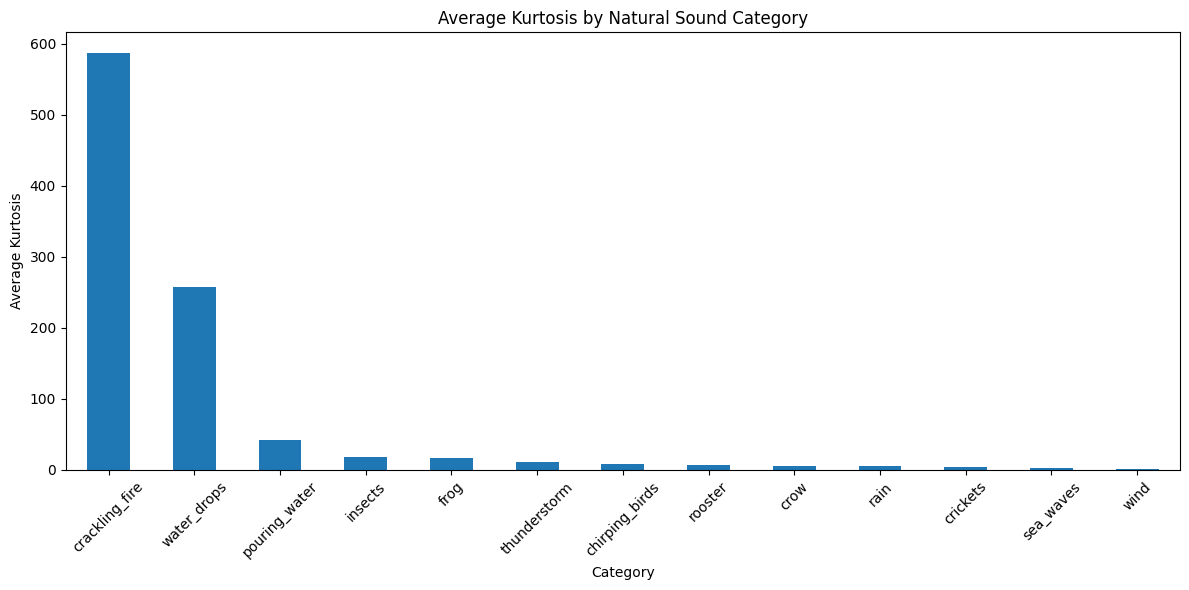

In [19]:
import matplotlib.pyplot as plt

mean_kurtosis = (
    features_df.groupby("category")["kurtosis"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
mean_kurtosis.plot(kind="bar")

plt.title("Average Kurtosis by Natural Sound Category")
plt.ylabel("Average Kurtosis")
plt.xlabel("Category")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

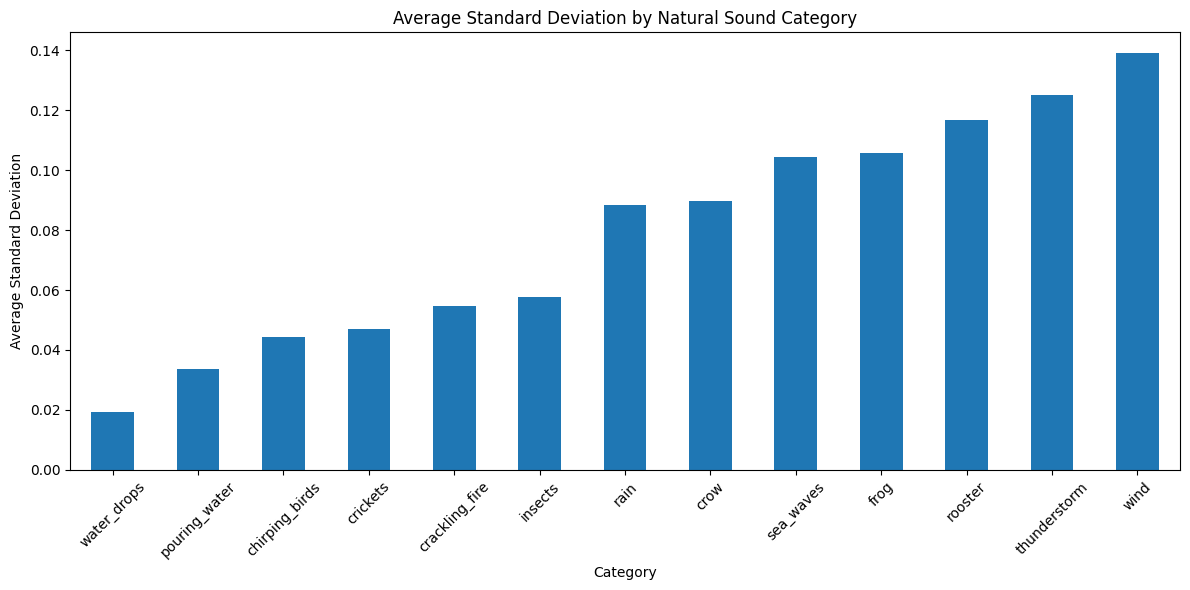

In [20]:
mean_std = (
    features_df.groupby("category")["std"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,6))
mean_std.plot(kind="bar")

plt.title("Average Standard Deviation by Natural Sound Category")
plt.ylabel("Average Standard Deviation")
plt.xlabel("Category")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Unsupervised Discovery of Natural Sound Groups

In [21]:
feature_matrix = features_df[
    ["mean", "std", "skewness", "kurtosis"]
]

feature_matrix.head()

,mean,std,skewness,kurtosis
0,-0.000001,0.061434,0.392988,10.404342
1,-0.000003,0.010946,0.157899,8.572530
2,-0.000010,0.016860,-0.039740,10.883121
3,-0.000253,0.136177,0.027326,2.776779
4,-0.000025,0.063967,-0.052734,29.311878


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(feature_matrix)

print(X_scaled.shape)

(520, 4)


In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(520, 2)


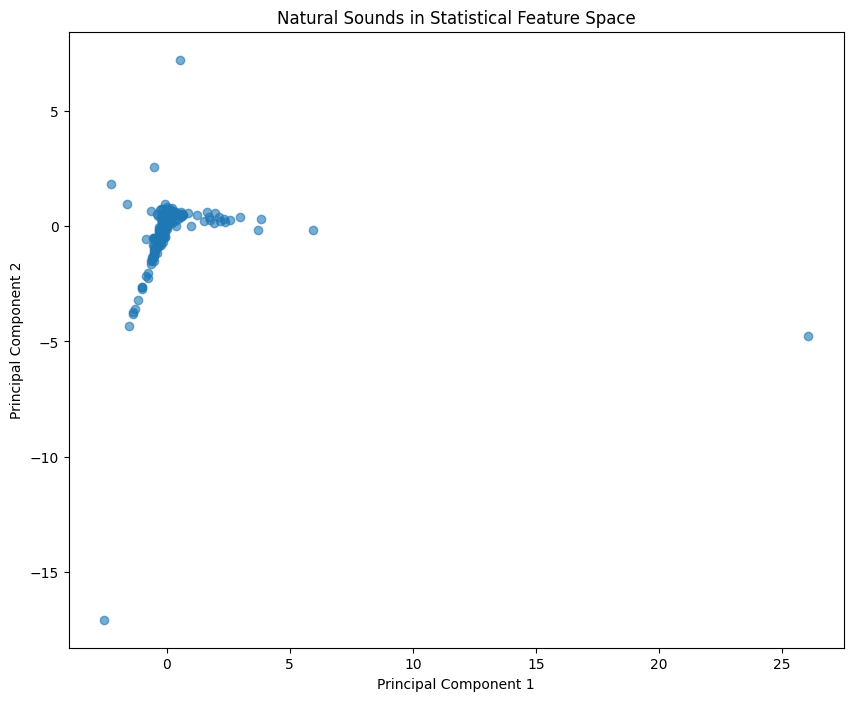

In [24]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.6
)

plt.title("Natural Sounds in Statistical Feature Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [26]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.4111907  0.29099545]

Total Variance Explained:
0.7021861


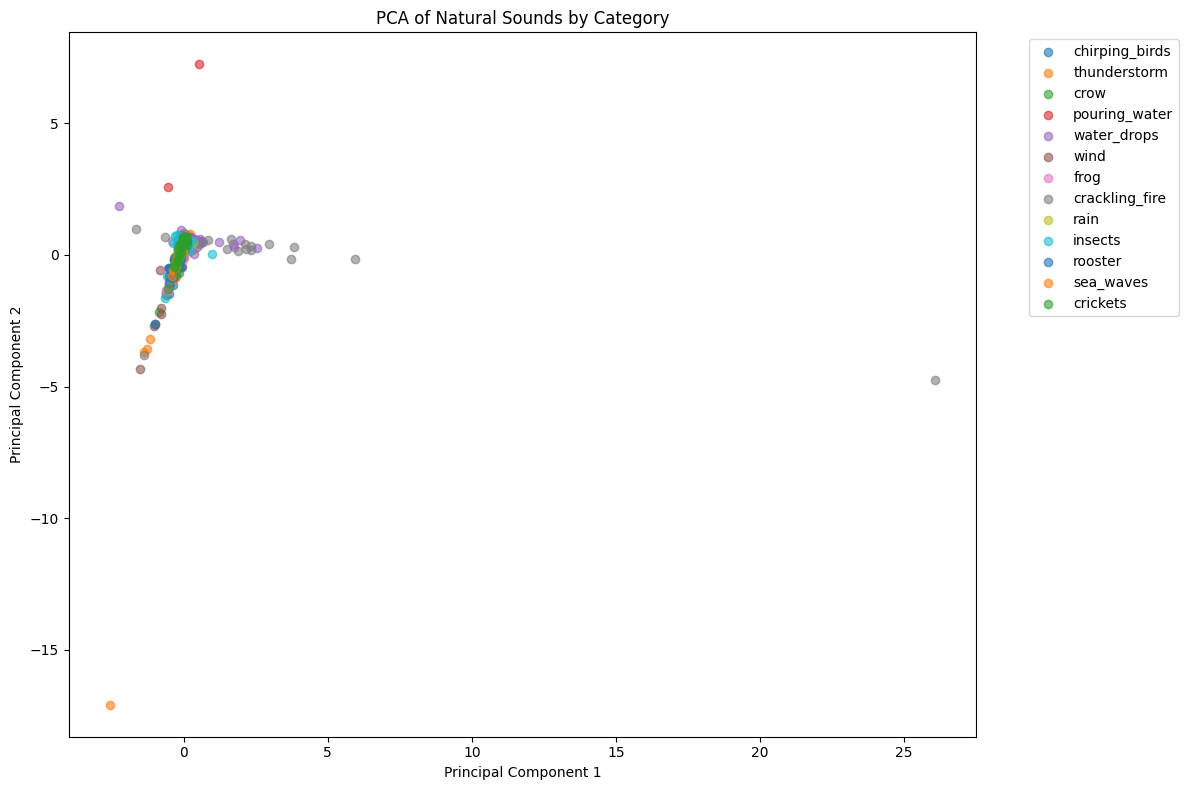

In [27]:
plt.figure(figsize=(12,8))

for category in features_df["category"].unique():

    subset = features_df["category"] == category

    plt.scatter(
        X_pca[subset,0],
        X_pca[subset,1],
        label=category,
        alpha=0.6
    )

plt.title("PCA of Natural Sounds by Category")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()